Nome: Lucas Fiuza Garcia

RA: 300901

Curso: Engenharia elétrica



# Ex04 - Filtragem de Imagens

Nesta atividade vamos entender a operação de convolução e o uso da mesma para filtragem de imagens. Testaremos o uso de **filtros suavizantes**, usados para a remoção de ruído, e **filtros aguçantes**, usados para detecção de bordas.  

- **Filtros suavizantes:** são aqueles que removem a nitidez da imagem fazendo uma média, aritmética ou ponderada, na janela do núcleo. O filtro ponderado suavizante mais comum é o da gaussiana. Filtros suavizantes são muito utilizados para eliminar ruído de uma imagem.

- **Filtros aguçantes:** são aqueles que realçam as bordas da imagem. Alguns dos filtros aguçantes comuns são: Filtro de Sobel, Filtro de Prewitt, Filtro Laplaciano.

Veja mais no notebook sobre [Filtragem no domínio espacial](https://github.com/lrittner/Computacao-Visual/blob/master/tutoriais/07_Filtragem_no_dominio_espacial.ipynb)

In [26]:
# Importando as bibliotecas que serão utilizadas
import os
import random
import shutil

import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import numpy as np
import requests
from PIL import Image

Download das imagens:

In [27]:
zip_url = r"https://raw.githubusercontent.com/UNICAMP-EA979/EA979-Recursos/main/FiltragemDeImagens.zip"

if not os.path.exists("FiltragemDeImagens.zip"):
    response = requests.get(zip_url)
    with open("FiltragemDeImagens.zip", mode="wb") as file:
        file.write(response.content)

if not os.path.exists("FiltragemDeImagens"):
    shutil.unpack_archive("FiltragemDeImagens.zip")

In [28]:
path = "FiltragemDeImagens/"

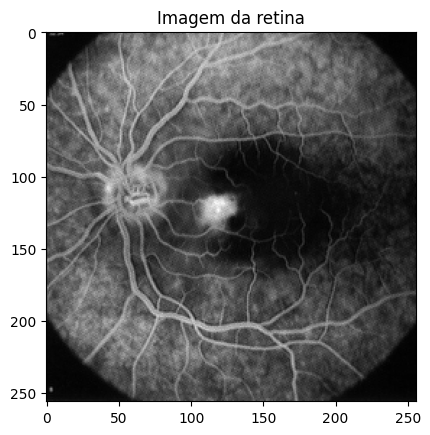

In [29]:
%matplotlib inline
f = mpimg.imread(path+'retina.tif')
plt.title('Imagem da retina')
plt.imshow(f,cmap='gray')

**ATENÇÃO** - as operações de filtragem alteram os valores e eles podem sair da faixa de 0 a 255. Portanto, fique atento à maneira como você está realizando as operações e visualizando os resultados. Algumas dicas:

- Uma boa prática é realizar as operações em ponto flutuante;
- Quando a visualização não corresponde ao esperado, desconfie que os valores sairam da escala e que os valores, de alguma maneira, estão sendo truncados.

## Parte 1 - Operação de convolução e filtro da média

### Exercício 1.1

Entenda o uso da operação de convolução e experimente usá-la para entender o filtro da média. Siga o seguinte roteiro:
- Crie uma imagem numérica pequena (7x7, por exemplo), crie um filtro de média (kernel 3x3) e use a função **convolve()** da biblioteca **scipy.ndimage** para realizar a filtragem. Verifique numericamente que a filtragem está correta;
- Repita a operação de filtragem na imagem da retina e visualize o resultado;
- Faça experimentos com a imagem da retina variando o tamanho do filtro e compare as imagens resultantes;
- Não se esqueça de comentar os métodos utilizados e resultados obtidos.

In [30]:
# Seu código aqui
from scipy.ndimage import convolve

img = np.array([
    [18, 18, 18, 18, 18, 18, 18],
    [18, 54, 54, 54, 54, 54, 18],
    [18, 54, 99, 99, 99, 54, 18],
    [18, 54, 99,108, 99, 54, 18],
    [18, 54, 99, 99, 99, 54, 18],
    [18, 54, 54, 54, 54, 54, 18],
    [18, 18, 18, 18, 18, 18, 18]
], dtype=float)

kernel = np.ones((3,3)) / 9
filtered = convolve(img, kernel, mode='constant', cval=0)


print("Imagem original:\n", img)
print("\nImagem filtrada:\n", filtered)


Imagem original:
 [[ 18.  18.  18.  18.  18.  18.  18.]
 [ 18.  54.  54.  54.  54.  54.  18.]
 [ 18.  54.  99.  99.  99.  54.  18.]
 [ 18.  54.  99. 108.  99.  54.  18.]
 [ 18.  54.  99.  99.  99.  54.  18.]
 [ 18.  54.  54.  54.  54.  54.  18.]
 [ 18.  18.  18.  18.  18.  18.  18.]]

Imagem filtrada:
 [[ 12.  20.  24.  24.  24.  20.  12.]
 [ 20.  39.  52.  57.  52.  39.  20.]
 [ 24.  52.  75.  85.  75.  52.  24.]
 [ 24.  57.  85. 100.  85.  57.  24.]
 [ 24.  52.  75.  85.  75.  52.  24.]
 [ 20.  39.  52.  57.  52.  39.  20.]
 [ 12.  20.  24.  24.  24.  20.  12.]]


observando a imagem filtrada, é possível confirmar o funcionamento do filtro de média 3x3, com alguns exemplos sendo o valor central 108 que se tornou 100 ao realizar a média de ((99 * 8 + 108) / 9 = 900 / 9 = 100), assim como outros valores ao longo da imagem. Além disso, é possível perceber que o modo 'constant' com cval = 0 está adicionando corretamente um padding constante de valor zero ao redor da imagem para a convolução, quando consideramos as bordas (Exemplo do primeiro valor: (0 * 5 +18 * 3 + 54) / 9 = 108 / 9 = 12)

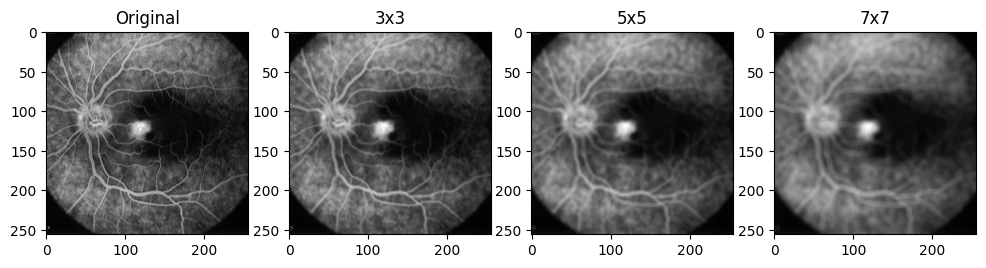

In [6]:
kernels = {
    '3x3': np.ones((3,3))/9,
    '5x5': np.ones((5,5))/25,
    '7x7': np.ones((7,7))/49
}

plt.figure(figsize=(12,4))

plt.subplot(1,4,1)
plt.title('Original')
plt.imshow(f, cmap='gray')

i = 2
for nome, k in kernels.items():
    f_temp = convolve(f, k)

    plt.subplot(1,4,i)
    plt.title(nome)
    plt.imshow(f_temp, cmap='gray')
    i += 1

plt.show()

No código acima, foram testados filtros de média de tamanho 3x3, 5x5 e 7x7 na imagem da retina, e é possível perceber a imagem sendo "borrada", conforme os traços são suavizados ao realizar a média do local onde se encontram. Além disso, é possível perceber que quanto maior o tamanho do filtro, mais intenso é o efeito, com a imagem do kernel 7x7 sendo a mais borrada das 3 e a do kernel 3x3 sendo a mais próxima à original, aplicando uma suavização leve na imagem.

### Exercício 1.2

Repita a operação de filtragem, desta vez variando também o modo de tratamento de borda da função **convolve()** - '*reflect*', '*constant*', '*nearest*', '*mirror*', '*wrap*' - explicando as diferenças encontradas. Dica, você só conseguirá visualizar as diferenças se aumentar o tamanho da máscara (filtro).

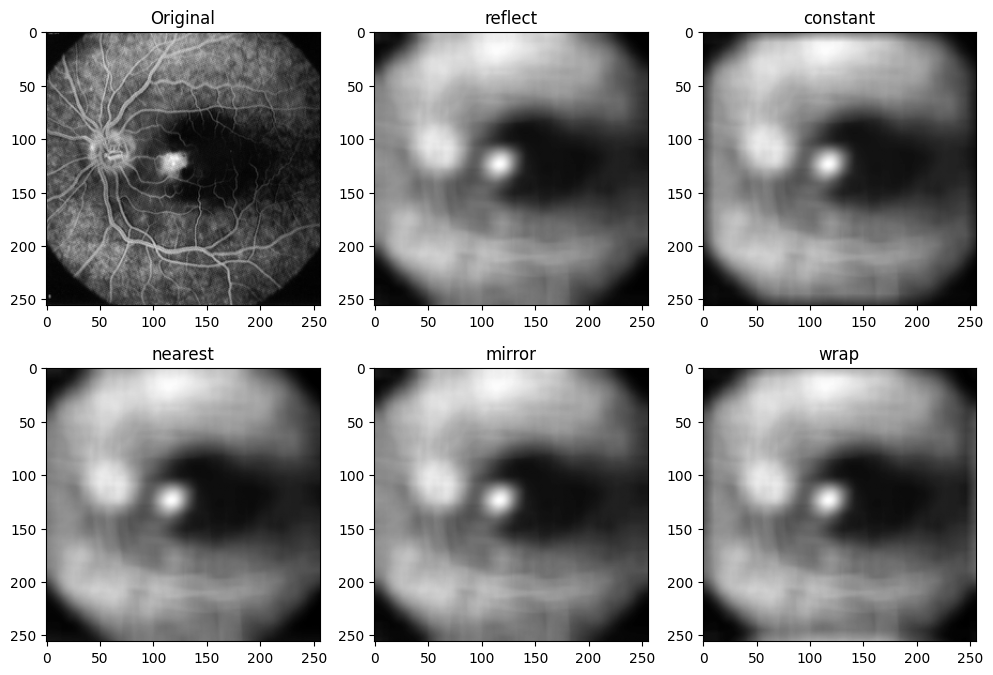

In [55]:
# Seu código aqui
kernel = np.ones((21,21)) / 441

modos = ['reflect', 'constant', 'nearest', 'mirror', 'wrap']

plt.figure(figsize=(12,8))

plt.subplot(2,3,1)
plt.title('Original')
plt.imshow(f, cmap='gray')

for i, modo in enumerate(modos):
    f_temp = convolve(f, kernel, mode=modo, cval=0)

    plt.subplot(2,3,i+2)
    plt.title(modo)
    plt.imshow(f_temp, cmap='gray')

plt.show()


Utilizando um filtro incrívelmente maior, as diferenças entre os métodos ficam mais visíveis:
- Reflect e Mirror

## Parte 2 - Filtro gaussiano e redução de ruído

### Exercício 2.1

Teste a propriedade de decomposição das máscaras da convolução, ou seja, crie um filtro gaussiano bi-dimensional (3,3) a partir de 2 filtros unidimensionais (3,1) e (1,3). Crie também o filtro bi-dimensional diretamente e cheque se os resultados são equivalentes. Comente os métodos utilizados.

In [77]:
# Seu código aqui
kernel_horiz = np.array([[1,2,1]], dtype=float)
kernel_vert = np.array([[1],
                        [2],
                        [1]], dtype=float)
kernel_gaussiano_decomposto = np.outer(kernel_horiz, kernel_vert)
print("kernel criado à partir dos unidimensionais:\n", kernel_gaussiano_decomposto)

kernel_gaussiano_direto = np.array([[1,2,1],
                             [2,4,2],
                             [1,2,1]], dtype=float)
print("\nkernel gaussiano direto:\n", kernel_gaussiano_direto)

kernel criado à partir dos unidimensionais:
 [[1. 2. 1.]
 [2. 4. 2.]
 [1. 2. 1.]]

kernel gaussiano direto:
 [[1. 2. 1.]
 [2. 4. 2.]
 [1. 2. 1.]]


Esse código simples, demonstra como o filtro gerado pela combinação de 2 filtros unidimensionais [1, 2, 1] gerou o mesmo filtro que o gaussiano [1, 2, 1], [2, 4, 2], [1, 2, 1], demonstrando diretamente a propriedade de decomposição.

In [101]:
def gaussiano_1d(tamanho=3, sigma=0.85):
  k = tamanho // 2
  x = np.arange(-k, k+1)

  g = np.exp(-(x**2) / (2 * sigma**2))
  g = g / g.sum()  # normalização

  return g
g1d = gaussiano_1d(tamanho=3, sigma=0.85)
g_row = g1d.reshape(1, 3)
g_col = g1d.reshape(3, 1)
kernel_gaussiano_decomposto = np.outer(g_row, g_col)
kernel_gaussiano_decomposto = kernel_gaussiano_decomposto / kernel_gaussiano_decomposto.sum()
print("kernel criado à partir dos unidimensionais:\n", kernel_gaussiano_decomposto.round(4))


# Gaussiana 2D (direta)
x, y = np.meshgrid(np.linspace(-1,1,3), np.linspace(-1,1,3))
d = x*x+y*y
sigma = 0.85
kernel_gaussiano_direto = (1./(2.*np.pi*sigma**2)) * np.exp(-d/(2.*sigma**2))
kernel_gaussiano_direto = kernel_gaussiano_direto/kernel_gaussiano_direto.sum()
print("\nkernel gaussiano direto:\n", kernel_gaussiano_direto.round(4))

#Arredondando para comparar com o código mais simples
kernel_gaussiano_direto = kernel_gaussiano_direto*16
kernel_gaussiano_decomposto = kernel_gaussiano_decomposto*16
print("\nkernel gaussiano à partir dos unidimensionais (arredondado):\n", kernel_gaussiano_decomposto.round(2))
print("\nkernel gaussiano direto (arredondado):\n", kernel_gaussiano_direto.round(2))

kernel criado à partir dos unidimensionais:
 [[0.0626 0.125  0.0626]
 [0.125  0.2497 0.125 ]
 [0.0626 0.125  0.0626]]

kernel gaussiano direto:
 [[0.0626 0.125  0.0626]
 [0.125  0.2497 0.125 ]
 [0.0626 0.125  0.0626]]

kernel gaussiano à partir dos unidimensionais (arredondado):
 [[1. 2. 1.]
 [2. 4. 2.]
 [1. 2. 1.]]

kernel gaussiano direto (arredondado):
 [[1. 2. 1.]
 [2. 4. 2.]
 [1. 2. 1.]]


Esse código realiza o mesmo teste com filtros gaussianos gerados à partir da fórmula contínua e, observando seu resultado também é possível perceber que os 2 filtros gerados são equivalentes (também é possível perceber que a aproximação deles resulta nos mesmos filtros utilizados no código mais simples)

### Exercício 2.2

Teste a aplicação de filtros suavizantes para redução de ruído: Adicione ruído gaussiano à imagem da retina (sugestão: use **np.random**) e depois tente remover o ruído com o filtro da média e com o filtro gaussiano. Você pode aumentar os filtros se quiser. Comente os métodos utilizados e resultados obtidos.

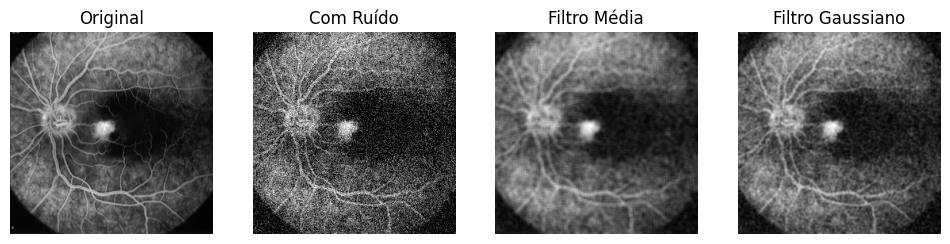

In [9]:
# Seu código aqui
ruido = np.random.normal(0, 40, f.shape)
f_ruidosa = f + ruido
f_ruidosa = np.clip(f_ruidosa, 0, 255)

kernel_media = np.ones((5,5)) / 25
f_media = convolve(f_ruidosa, kernel_media, mode='reflect')

kernel_gauss = np.array([[ 1, 4, 7, 4, 1],
                         [ 4,16,26,16, 4],
                         [ 7,26,41,26, 7],
                         [ 4,16,26,16, 4],
                         [ 1, 4, 7, 4, 1],], dtype=float)
f_gauss = convolve(f_ruidosa, kernel_gauss, mode='reflect')

plt.figure(figsize=(12,6))

plt.subplot(1,4,1)
plt.title('Original')
plt.imshow(f, cmap='gray')
plt.axis('off')

plt.subplot(1,4,2)
plt.title('Com Ruído')
plt.imshow(f_ruidosa, cmap='gray')
plt.axis('off')

plt.subplot(1,4,3)
plt.title('Filtro Média')
plt.imshow(f_media, cmap='gray')
plt.axis('off')

plt.subplot(1,4,4)
plt.title('Filtro Gaussiano')
plt.imshow(f_gauss, cmap='gray')
plt.axis('off')

plt.show()

## Parte 3 - Filtro de Sobel e detecção de bordas

Existem vários filtros que procuram realçar as bordas da imagem. Um dos mais conhecidos é o Operador Sobel, composto por uma máscara vertical (Sv) e uma máscara horizontal (Sh).

In [10]:
Sv = np.array([[1,0,-1],[2,0,-2],[1,0,-1]])
print('Sv =\n',Sv)

Sh = np.array([[1,2,1],[0,0,0],[-1,-2,-1]])
print('Sh =\n',Sh)

Sv =
 [[ 1  0 -1]
 [ 2  0 -2]
 [ 1  0 -1]]
Sh =
 [[ 1  2  1]
 [ 0  0  0]
 [-1 -2 -1]]


Para detectar bordas de uma imagem usando o Filtro de Sobel, precisamos fazer a filtragem da imagem usando tanto a máscara vertical, quanto a horizontal. No final, acabaremos com 2 imagens resultantes, uma reforçando as bordas verticais e outra reforçando as bordas horizontais, como exemplificado abaixo.

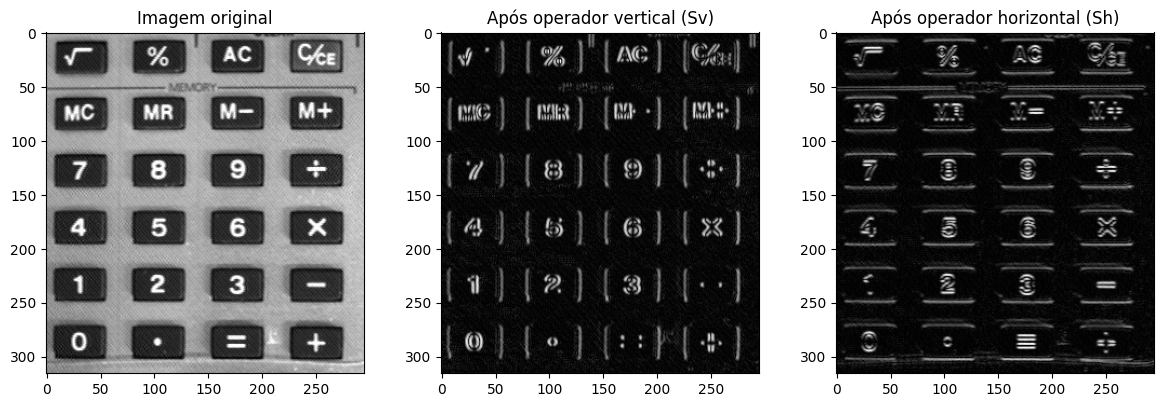

In [11]:
img = mpimg.imread(path+'keyb.tif')
img_sv = mpimg.imread(path+'keyb_sv.tif')
img_sh = mpimg.imread(path+'keyb_sh.tif')

fig, axs = plt.subplots(1,3, figsize=(12, 4))
plt.tight_layout()

plt.subplot(131)
plt.imshow(img, cmap='gray')
plt.title('Imagem original')

plt.subplot(132)
plt.imshow(img_sv,cmap='gray')
plt.title('Após operador vertical (Sv)')

plt.subplot(133)
plt.imshow(img_sh,cmap='gray')
plt.title('Após operador horizontal (Sh)');

### Exercício 3.1 - Visualizando as bordas verticais e horizontais em 2 imagens separadas

Experimente filtrar as imagens abaixo com os Filtros de Sobel vertical e horizontal e visualize o resultado. Para cada imagem, você deve obter uma imagem fitrada pelo Filtro de Sobel vertical - **fv** - e uma imagem filtrada pelo Filtro de Sobel horizontal - **fh**. Comente sobre os resultados obtidos. As imagens geradas estão de acordo com o exemplo apresentado para a imagem da calculadora? Em caso negativo, explique o porquê e tente fazer com que as imagens fiquem mais semelhantes.

In [12]:
img1 = mpimg.imread(path+'retina.tif')

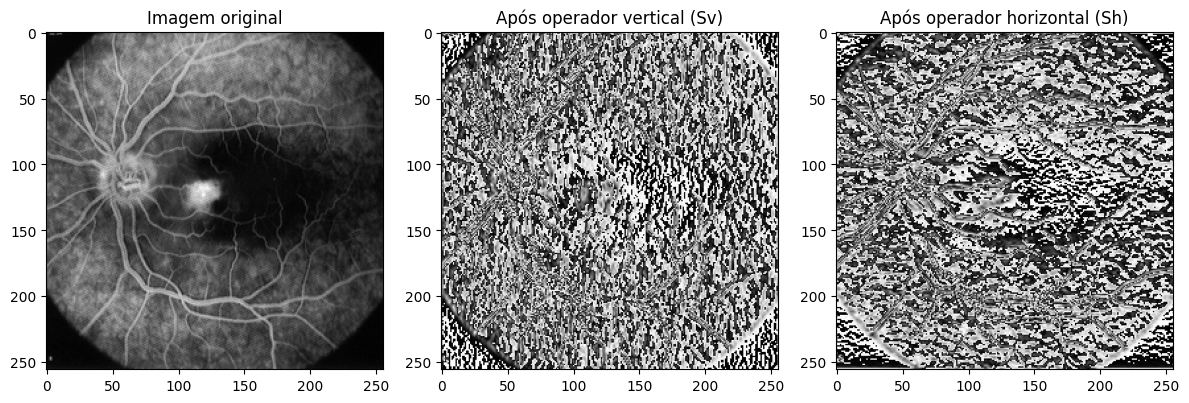

In [13]:
# Seu código aqui
img1_sv = convolve(img1, Sv, mode='constant', cval=0)
img1_sh = convolve(img1, Sh, mode='constant', cval=0)

fig, axs = plt.subplots(1,3, figsize=(12, 4))
plt.tight_layout()

plt.subplot(131)
plt.imshow(img1, cmap='gray')
plt.title('Imagem original')

plt.subplot(132)
plt.imshow(img1_sv,cmap='gray')
plt.title('Após operador vertical (Sv)')

plt.subplot(133)
plt.imshow(img1_sh,cmap='gray')
plt.title('Após operador horizontal (Sh)');

---

In [14]:
img2 = mpimg.imread(path+'cameraman.tif')

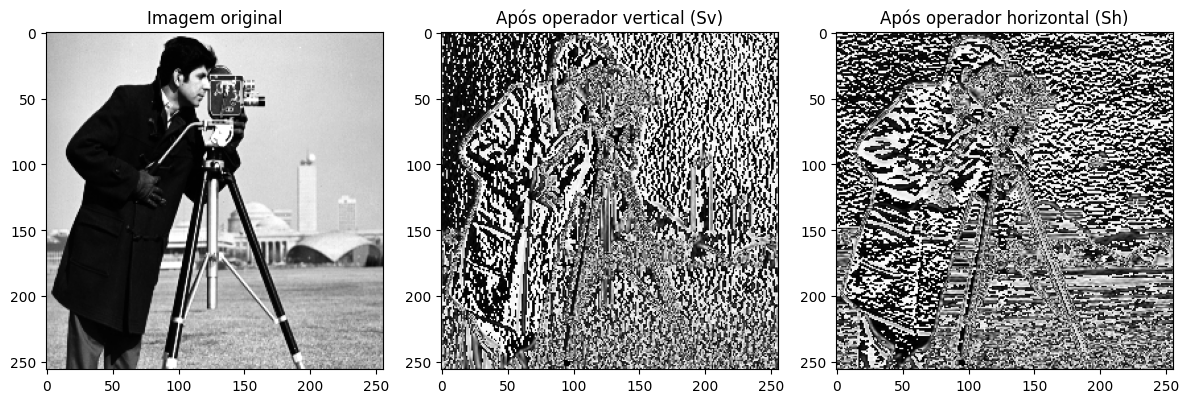

In [15]:
# Seu código aqui
img2_sv = convolve(img2, Sv, mode='constant', cval=0)
img2_sh = convolve(img2, Sh, mode='constant', cval=0)

fig, axs = plt.subplots(1,3, figsize=(12, 4))
plt.tight_layout()

plt.subplot(131)
plt.imshow(img2, cmap='gray')
plt.title('Imagem original')

plt.subplot(132)
plt.imshow(img2_sv,cmap='gray')
plt.title('Após operador vertical (Sv)')

plt.subplot(133)
plt.imshow(img2_sh,cmap='gray')
plt.title('Após operador horizontal (Sh)');

### Exercício 3.2 - Visualizando todas as bordas em uma única imagem

Para visualizar o resultado das 2 filtragens (horizontal e vertical) em uma única imagem, utilizamos a magnitude de Sobel. A função MagSobel (a ser implementada) possui como parâmetro a imagem de entrada e deve seguir a seguinte equação:

$$MagSobel = \sqrt{f_h^2 + f_v^2}$$

onde $f_h$ é a imagem de entrada convolvida com o operador de Sobel horizontal e $f_v$ é a imagem de entrada convolvida com o operador de Sobel vertical. Crie esta função e visualize a Magnitude de Sobel das imagens utilizadas no exercício 3.1.

In [16]:
# Seu código aqui

## Parte 4 - Aprendendo filtros com CNN (opcional para EA979)

Como vimos em sala de aula, as redes neurais convolucionais (CNNs, do inglês *convolutional neural networks*) têm como base as camadas convolucionais, um banco de filtros cujos pesos são aprendidos a partir de um gabarito para predição. Para entender melhor como isso funciona, vamos praticar com redes convolucionais bem simples e visualizar como os filtros são aprendidos por elas.

Vamos utilizar um conjunto de dados composto por 60 imagens de cidades, que servirão como entradas para a nossa rede. Além das imagens originais, temos também outros dois conjuntos de imagens, obtidos após a aplicação de dois tipos de filtros diferentes nas imagens originais (Dica: ambos os filtros aplicados foram filtros vistos anteriormente neste notebook). Essas imagens filtradas servirão como nosso gabarito para que a CNN possa aprender automaticamente qual filtro foi aplicado em cada conjunto de dados, ou seja, a rede vai tentar aprender qual o filtro necessário para obter o gabarito (imagem filtrada) a partir da entrada (imagem original).

**Para mais informações sobre redes convolucionais, exemplos e boas práticas, verifique os materiais de apoio disponibilizados no classroom. Lá você vai encontrar um tutorial teórico sobre CNN, além de tutoriais práticos disponibilizados no GitHub. Recomendamos utilizar a biblioteca PyTorch, que será utilizada novamente em exercícios futuros.**

Abaixo, visualizamos uma imagem aleatória do conjunto e suas respectivas versões filtradas.

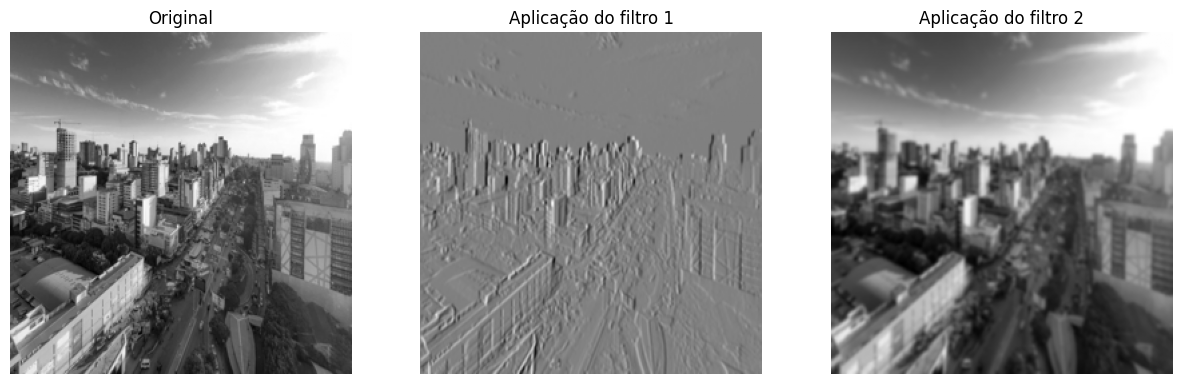

In [22]:
path_dataset = path + 'City_images/'
selec_img = random.randint(1, 60)

img_ori = Image.open(path_dataset+'imgs_originais/'+f'{selec_img}.tif')
img_f1 = Image.open(path_dataset+'imgs_filt1/'+f'{selec_img}.tif')
img_f2 = Image.open(path_dataset+'imgs_filt2/'+f'{selec_img}.tif')

plt.figure(figsize=(15,5))
plt.subplot(131)
plt.imshow(np.array(img_ori), cmap='gray')
plt.axis('off')
plt.title('Original')
plt.subplot(132)
plt.imshow(np.array(img_f1), cmap='gray')
plt.axis('off')
plt.title('Aplicação do filtro 1')
plt.subplot(133)
plt.imshow(np.array(img_f2), cmap='gray')
plt.axis('off')
plt.title('Aplicação do filtro 2');

Para facilitar a visualização dos filtros aprendidos pela rede, vamos utilizar o código abaixo, que gera um **gif** a partir de um conjunto de arrays. Tente entender o código a partir do exemplo dado.

In [23]:
# Criando um conjunto de arrays para exemplificar o código
array_list = []
array_inicial = np.array([[0,0,0,0,0,0,0,0,0,0,0,0]]*6, dtype='uint8')
array_list.append(array_inicial)
for i in range(12):
    tmp = array_inicial.copy()
    tmp[2:4,:i+1] = 1
    array_list.append(tmp)

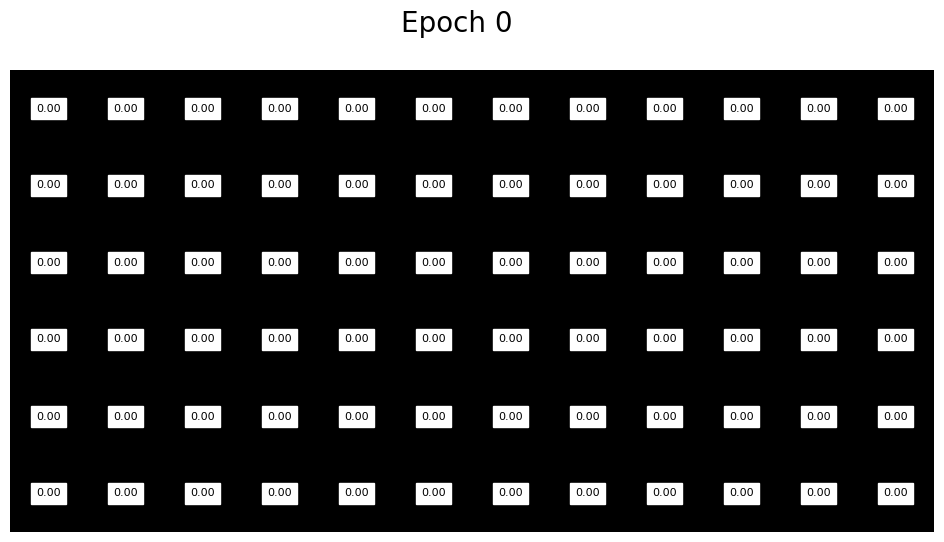

In [25]:
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

# Gif generation
images = np.array(array_list)
vmin = images.min()
vmax = images.max()
fig = plt.figure(figsize=(12,6))

# Function to update the image and add text annotations
def update(frame):
    plt.clf()  # Clear the previous plot
    fig.suptitle("Epoch {}".format(frame), fontsize=20) # Define the title
    plt.imshow(images[frame], vmin=vmin, vmax=vmax, cmap='gray') # Generate the image
    plt.axis('off')
    # Add text annotations
    for (i, j), value in np.ndenumerate(images[frame]):
        plt.text(j, i, f'{value:.2f}', ha='center', va='center', color='black', fontsize=8, backgroundcolor='white')

# Creating the animation
anim = FuncAnimation(fig, update, frames=len(images), interval=200)
# Displaying the animation in the notebook
html = anim.to_jshtml()
HTML(html)

### Exercício 4.1

Crie uma CNN composta por apenas uma camada convolucional com kernel de tamanho 3x3, que utilize as imagens originais como entrada e tenha como "gabarito" o primeiro conjunto de imagens filtradas (**imgs_filt1**). Você precisará definir uma função de loss, um otimizador para a rede e o número de épocas para treinamento. Então, treine a rede com as imagens especificadas, acompanhando os valores de loss a cada época. Você deve armazenar em uma lista os pesos do kernel da rede a cada época do treinamento.

Após o treinamento, visualize a progressão dos pesos do kernel utilizando o código de geração de **gif** dado anteriormente. Comente os métodos utilizados e resultados obtidos. A partir do **gif** obtido, você é capaz de dizer que filtro foi utilizado para gerar o conjunto de imagens da pasta **imgs_filt1**?

In [20]:
# Seu código aqui

### Exercício 4.2

Repita o processo realizado no exercício 5.1, mas dessa vez crie uma CNN composta por duas camadas convolucionais, a primeira com kernel de tamanho 1x5 e a segunda com kernel de tamanho 5x1. Você deve utilizar como "gabarito" o segundo conjunto de imagens filtradas (**imgs_filt2**). Armazene os pesos dos kernels da rede a cada época do treinamento em duas listas, uma para cada kernel.

Após o treinamento, visualize a progressão dos pesos de cada kernel utilizando o código de geração de **gif** dado anteriormente. Comente os métodos utilizados e resultados obtidos. A partir dos **gifs** obtidos, você é capaz de dizer que filtro foi utilizado para gerar o conjunto de imagens da pasta **imgs_filt2**?

In [21]:
# Seu código aqui